In [1]:
import os
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from shapely.geometry import Polygon, Point
import cartopy.feature as feature
from cartopy import crs as ccrs
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import gsw

from scipy.signal import welch


In [ ]:
#NEKE and mask med
eke = xr.open_dataset('../../../Med_Global_EKE/processed_data/GLO/ALL_SAT/NEKE_ALL_SAT_GLO_C3S_vDT2021_19930101_20230607.nc')
mask_med = np.load('../../../Med_Global_EKE/results/masks/2mask_MED_GLO.npy', allow_pickle=True)
eke = eke.where(mask_med)
eke = eke.rename({"EKE": "eke"})
# Open, cut, sort L4
#2mask_MED_MED pour allsatmed
data_path = [
            #  '../../data/med_allsat_L4_008_068/vDT2021/', 
             '../../../Med_Global_EKE/data/glo_allsat_L4_008_047/vDT2021/',
             # '../../data/glo_twosat_L4_008_057/vDT2021/'
            ]
for k in range(len(data_path)):
    listd = os.listdir(data_path[k])
    listd.sort()
    listd = [item for item in listd if not item.startswith(".")]
    dsf = xr.Dataset()
    for year_folder in listd:
        year_path = os.path.join(data_path[k], year_folder)
        file = os.listdir(year_path)
        file = [f for f in file if not f.startswith(".")]
        ds = xr.open_dataset(os.path.join(year_path, file[0]))
        ds = ds[['ugosa', 'vgosa', 'ugos', 'vgos']]
        ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})
        ds['lon'] = xr.where(ds['lon'] > 180, ds['lon'] - 360, ds['lon'])
        dsf = xr.concat([dss for dss in [dsf, ds] if dss], dim='time')
    dsf['time'] = dsf['time'].dt.round("D")
    dsf['lon'] = xr.where(dsf['lon'] > 180, dsf['lon'] - 360, dsf['lon'])
dsf = dsf.where((dsf.lat >= 30) & (dsf.lat <= 47) & 
                       (dsf.lon >= -6) & (dsf.lon <= 37),
                       drop=True)
dsf = dsf.where(mask_med)
#create data avec neke and new uvgos and uvgosa
data = xr.Dataset({"eke": eke["eke"]}, 
     coords=eke.coords)

data["ugos"] = xr.DataArray(dsf["ugos"].values,
    dims=("time", "lat", "lon"), coords=eke.coords)
data["vgos"] = xr.DataArray(dsf["vgos"].values,
    dims=("time", "lat", "lon"), coords=eke.coords)
data["ugosa"] = xr.DataArray(dsf["ugosa"].values,
    dims=("time", "lat", "lon"), coords=eke.coords)
data["vgosa"] = xr.DataArray(dsf["vgosa"].values,
    dims=("time", "lat", "lon"), coords=eke.coords)

data['ugosa'] = data.ugosa - data.ugosa.mean(dim='time', skipna=False).compute()
data['vgosa'] = data.vgosa - data.vgosa.mean(dim='time', skipna=False).compute()

data.to_netcdf('../../data/neke_uvgos_a_dt2021.nc')

In [3]:
# Satellite data
data = xr.open_dataset('../../data/neke_uvgos_a_dt2021.nc')
# Model data
glorys = xr.open_dataset('../../data/001_030_glorys_uovo_sal_temp_boT_mld_zos.nc')
glorys = glorys.rename({'longitude': 'lon', 'latitude': 'lat'})
glorys = glorys.squeeze(dim="depth")

ensemble = xr.open_dataset('../../data/001_031_ensemble_uovo_sal_temp_mld_zos.nc')
ensemble = ensemble.rename({'longitude': 'lon', 'latitude': 'lat'})
ensemble = ensemble.squeeze(dim="depth")

In [4]:
# Cut region
def subset_region(ds, lonmin, lonmax, latmin, latmax):
    if ds.lat[0] < ds.lat[-1]:
        lat_slice = slice(latmin, latmax)
    else:
        lat_slice = slice(latmax, latmin)

    return ds.sel(lon=slice(lonmin, lonmax), lat=lat_slice)

In [5]:
# Regions
lonmin_alb, lonmax_alb, latmin_alb, latmax_alb = -5.4, -1, 35.2, 36.7
lonmin_iera, lonmax_iera, latmin_iera, latmax_iera = 25, 27, 33, 35
lonmin_med, lonmax_med, latmin_med, latmax_med = -10, 37, 30, 45

# Satellite data

In [6]:
R = 6371000

lat = data.lat.values
lon = data.lon.values

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

dlat = np.gradient(lat_rad)
dlon = np.gradient(lon_rad)

dx = R * np.cos(lat_rad)[:, None] * dlon
dy = R * dlat[:, None]
dy = np.repeat(dy, len(lon), axis=1)

dx = xr.DataArray(dx, coords={"lat": data.lat, "lon": data.lon}, dims=("lat","lon"))
dy = xr.DataArray(dy, coords={"lat": data.lat, "lon": data.lon}, dims=("lat","lon"))

In [7]:
# Turbulent momentums
uu = (data.ugosa*data.ugosa)
vv = (data.vgosa*data.vgosa)
uv = (data.ugosa*data.vgosa)
# Mean flows
umean = (data.ugos - data.ugosa).mean(dim='time')
vmean = (data.vgos - data.vgosa).mean(dim='time')
# Compute the derivatives
dudx = umean.differentiate("lon") / dx
dudy = umean.differentiate("lat") / dy
dvdx = vmean.differentiate("lon") / dx
dvdy = vmean.differentiate("lat") / dy
#BTR terms
btr_zonal = -uu * dudx  #zonal stretching
btr_meridional = -vv * dvdy #meridional stretching
btr_shear = -uv * (dvdx + dudy) #shear crossed
# Compute the BTR
btr_med = btr_zonal + btr_meridional + btr_shear
btr_med_mean = btr_med.mean(dim='time')

In [8]:
btr_alb = subset_region(btr_med, lonmin=lonmin_alb, lonmax=lonmax_alb, latmin=latmin_alb, latmax=latmax_alb)
btr_iera = subset_region(btr_med, lonmin=lonmin_iera, lonmax=lonmax_iera, latmin=latmin_iera, latmax=latmax_iera)

btr_alb_mean = btr_alb.mean(('lat', 'lon'))
btr_iera_mean = btr_iera.mean(('lat', 'lon'))
btr_med_mean = btr_med.mean(('lat', 'lon'))

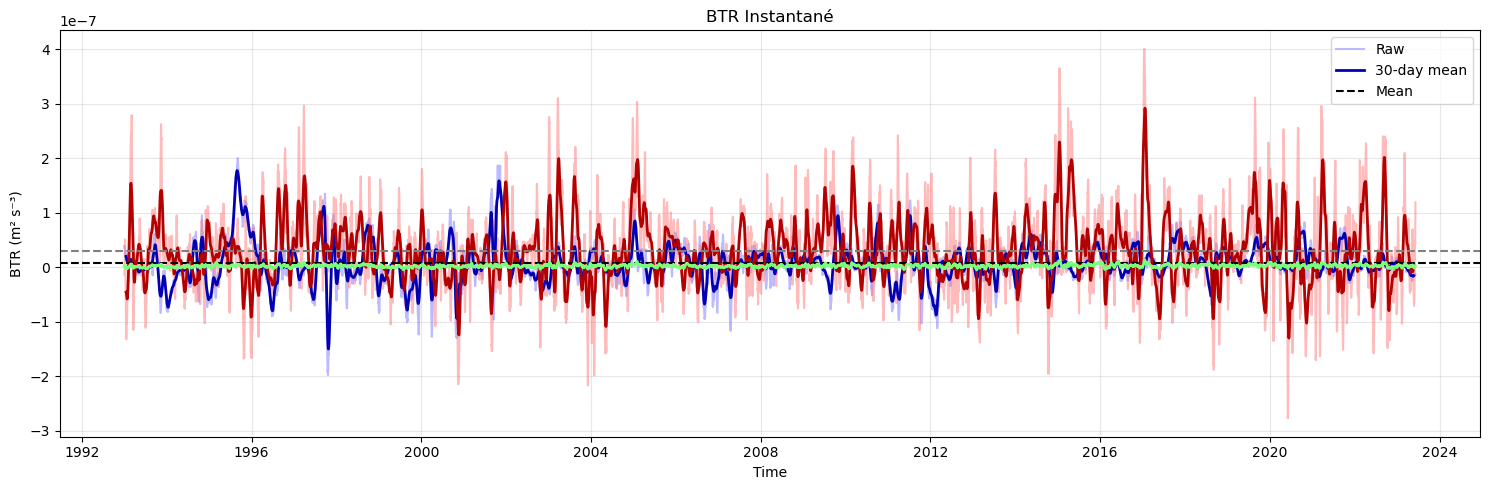

In [9]:
fig, ax = plt.subplots(figsize=(15, 5))

# signal brut
btr_iera_mean.plot(ax=ax, color="#7B79FF", alpha=0.5, label="Raw")
btr_alb_mean.plot(ax=ax, color="#FF7979", alpha=0.5)


# lissage (30 jours)
btr_smooth_iera = btr_iera_mean.rolling(time=30, center=True).mean()
btr_smooth_iera.plot(ax=ax, color="#0300B4", linewidth=2, label="30-day mean")
btr_smooth_alb = btr_alb_mean.rolling(time=30, center=True).mean()
btr_smooth_alb.plot(ax=ax, color="#B40000", linewidth=2)

# moyenne globale
ax.axhline(btr_iera_mean.mean(), color="k", linestyle="--", label="Mean")
ax.axhline(btr_alb_mean.mean(), color="grey", linestyle="--")

btr_med_mean.plot(ax=ax, color="#79FF7B", lw=2)

ax.set_title("BTR Instantané")
ax.set_ylabel("BTR (m² s⁻³)")
ax.grid(True, alpha=0.3)

ax.legend()
plt.tight_layout()
plt.show()

In [10]:
def zscore(x):
    return (x - x.mean()) / x.std()

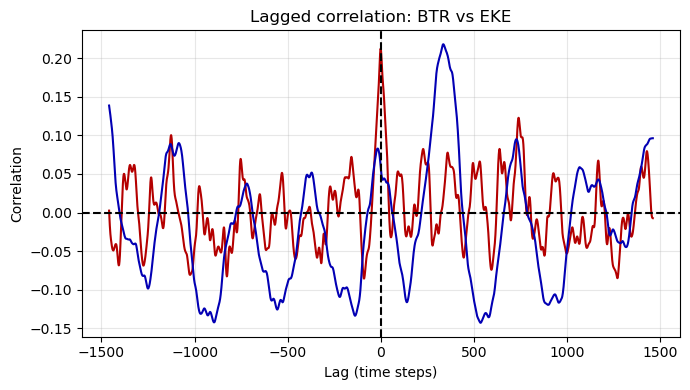

In [11]:
# --- séries temporelles ---
eke_t_alb = subset_region(data.eke, lonmin=lonmin_alb, lonmax=lonmax_alb, latmin=latmin_alb, latmax=latmax_alb)
eke_alb = eke_t_alb.mean(("lat","lon"))
eke_t_iera = subset_region(data.eke, lonmin=lonmin_iera, lonmax=lonmax_iera, latmin=latmin_iera, latmax=latmax_iera)
eke_iera = eke_t_iera.mean(("lat","lon"))

# --- normalisation ---
def zscore(x):
    return (x - x.mean()) / x.std()

btr_z_alb = zscore(btr_alb_mean)
eke_z_alb = zscore(eke_alb)
btr_z_iera = zscore(btr_iera_mean)
eke_z_iera = zscore(eke_iera)

# --- calcul corrélation avec lag ---
lags = np.arange(-365*4+1, 365*4+1)  # ±365 jours ou pas de temps

corrs_alb = []
corrs_iera = []

for lag in lags:
    corrs_alb.append(xr.corr(btr_z_alb, eke_z_alb.shift(time=lag)))
    corrs_iera.append(xr.corr(btr_z_iera, eke_z_iera.shift(time=lag)))


corrs_alb = xr.concat(corrs_alb, dim="lag")
corrs_alb["lag"] = lags
corrs_iera = xr.concat(corrs_iera, dim="lag")
corrs_iera["lag"] = lags


fig, ax = plt.subplots(figsize=(7,4))

corrs_alb.plot(ax=ax, label="Alboran", color="#B40000")
corrs_iera.plot(ax=ax, label="Iera", color="#0300B4")

ax.axhline(0, color="k", linestyle="--")
ax.axvline(0, color="k", linestyle="--")

ax.set_xlabel("Lag (time steps)")
ax.set_ylabel("Correlation")
ax.set_title("Lagged correlation: BTR vs EKE")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_766902/2194705023.py:13: RuntimeWarning: divide by zero encountered in divide
  period = 1 / freqs


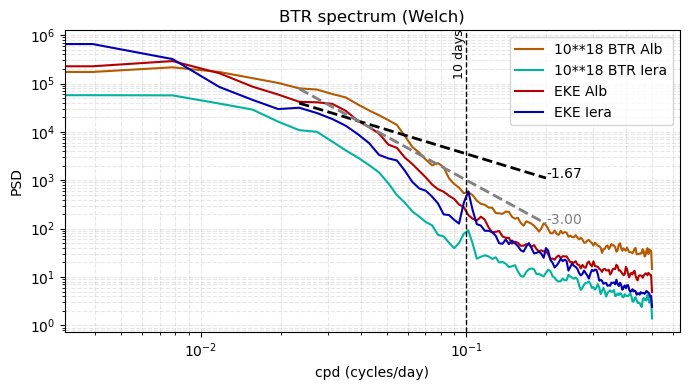

In [12]:
# fréquence d’échantillonnage (IMPORTANT)
# 1 point/jour → fs = 1
fs = 1  

# Welch
freqs, psd_btr_alb_mean = welch(btr_alb_mean, fs=fs, nperseg=256, detrend="linear")
freqs, psd_eke_alb = welch(eke_alb, fs=fs, nperseg=256, detrend="linear")

freqs, psd_btr_iera_mean = welch(btr_iera_mean, fs=fs, nperseg=256, detrend="linear")
freqs, psd_eke_iera = welch(eke_iera, fs=fs, nperseg=256, detrend="linear")


period = 1 / freqs

fig, ax = plt.subplots(figsize=(7,4))

ax.loglog(freqs, psd_btr_alb_mean*10**18, color="#B45A00", label="10**18 BTR Alb")
ax.loglog(freqs, psd_btr_iera_mean*10**18, color="#00B49F", label="10**18 BTR Iera")
ax.loglog(freqs, psd_eke_alb, color="#B40000", label="EKE Alb")
ax.loglog(freqs, psd_eke_iera, color="#0300B4", label="EKE Iera")

ax.set_xlabel("cpd (cycles/day)")
ax.set_ylabel("PSD")
ax.set_title("BTR spectrum (Welch)")
ax.legend()

periods_days = [10]
for p in periods_days:
    freq = 1 / p
    ax.axvline(freq, color="black", linestyle="--", linewidth=1)
    ax.text(freq, ax.get_ylim()[1] * 0.1,   # position verticale automatique
        f"{p} days", rotation=90, va="bottom", ha="right", fontsize=9)



# --- pentes ---
slopes = [-5/3, -3]
colors = ["black", "gray"]

f_ref = freqs[10]
scale = psd_eke_alb[10]

for slope_exp, c in zip(slopes, colors):
    
    mask = (freqs > 0.02) & (freqs < 0.2)
    
    slope = (freqs[mask] / f_ref) ** (slope_exp)
    slope *= scale

    ax.loglog(freqs[mask], slope, color=c, linestyle="--", linewidth=2)

    # annotation sur le plot
    ax.text(
        freqs[mask][-1],   # position x
        slope[-1],         # position y
        f"{slope_exp:.2f}",
        fontsize=10,
        color=c
    )



ax.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


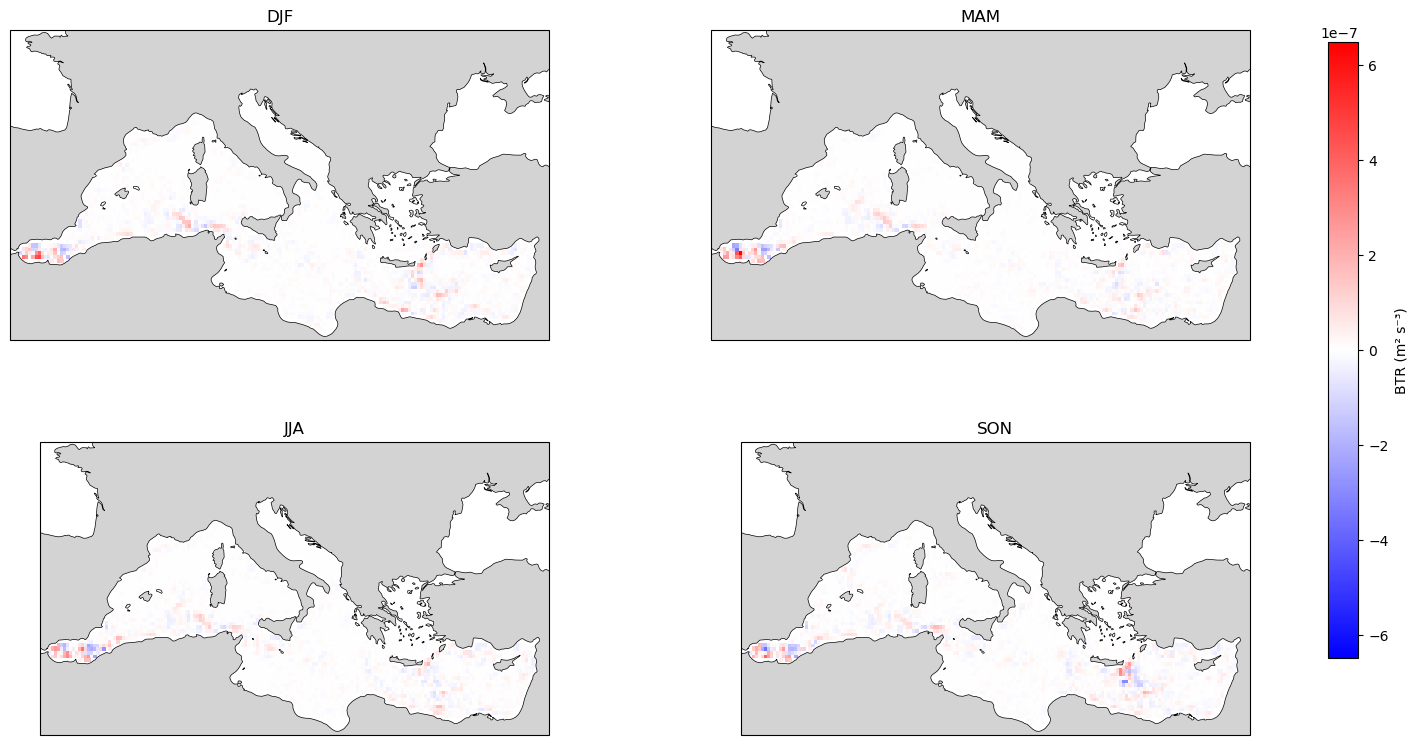

In [13]:
ccrs_land = feature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='black',
                                        facecolor='lightgray',
                                        linewidth=0.5)
levels = 99
lon_min = -10
lon_max = 37
lat_min = 30
lat_max = 47
# moyenne saisonnière
btr_season = btr_med.groupby("time.season").mean("time")
# ordre des saisons
seasons = ["DJF", "MAM", "JJA", "SON"]
# échelle commune
vmax = np.nanmax(np.abs(btr_season.values))
vmin = -vmax
# vmin= -1e-7
# vmax = 1e-7

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.1, wspace=0.3, height_ratios=[3, 2])

# Créer les axes
ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.Mercator())
ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.Mercator())
ax3 = fig.add_subplot(gs[1, 0], projection=ccrs.Mercator())
ax4 = fig.add_subplot(gs[1, 1], projection=ccrs.Mercator())

for ax, season in zip([ax1, ax2, ax3, ax4], seasons):

    data_plot = btr_season.sel(season=season)

    im = ax.pcolor(
        data_plot.lon,
        data_plot.lat,
        data_plot,
        transform=ccrs.PlateCarree(),
        cmap="bwr",
        vmin=vmin,
        vmax=vmax
    )

    ax.coastlines(linewidth=0.5)
    ax.add_feature(feature.LAND, facecolor="lightgray")
    ax.set_extent([-6, 37, 30, 47])

    ax.set_title(season)

# colorbar
fig.colorbar(im, ax=[ax1, ax2, ax3, ax4], shrink=0.8, label="BTR (m² s⁻³)")

plt.show()

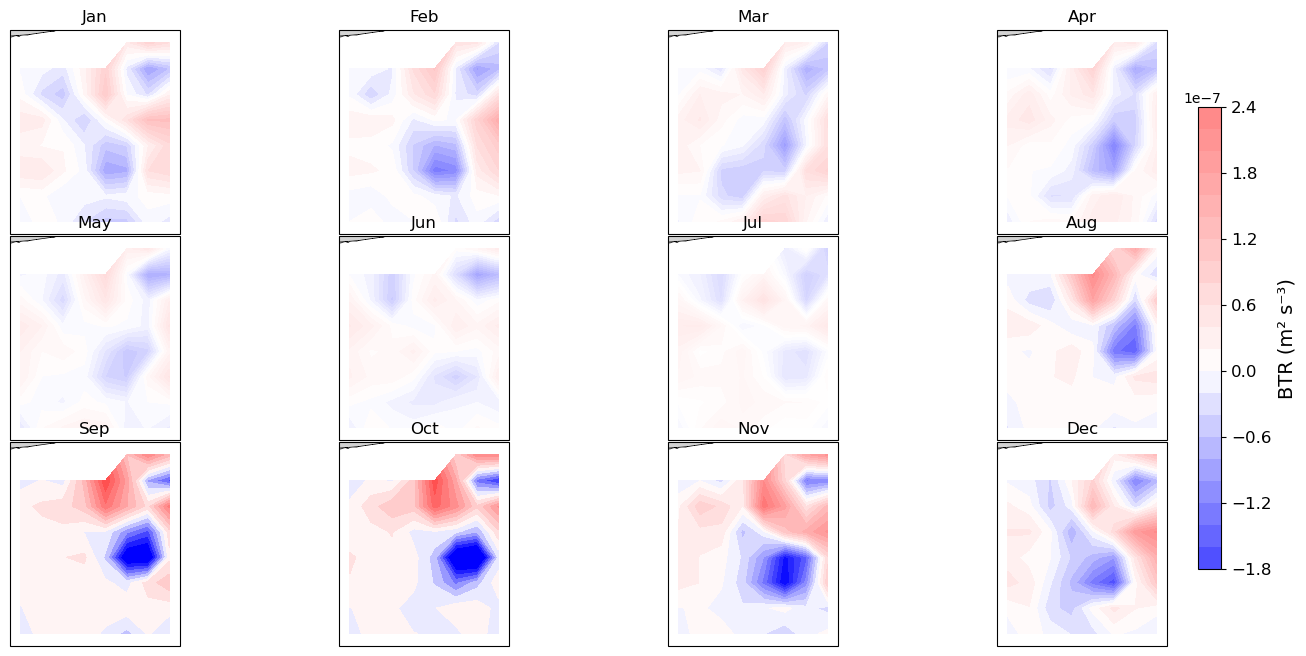

In [14]:
# --- land ---
ccrs_land = feature.NaturalEarthFeature(
    'physical', 'land', '50m',
    edgecolor='black',
    facecolor='lightgray',
    linewidth=0.5
)

# --- moyenne mensuelle ---
btr_month = btr_iera.groupby("time.month").mean("time")

# --- mois ---
months = np.arange(1, 13)

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

# --- limites ---
lon_min, lon_max = lonmin_iera, lonmax_iera
lat_min, lat_max = latmin_iera, latmax_iera

# --- échelle commune ---
# vmax = np.nanmax(np.abs(btr_month.values))
# vmin = -vmax
vmin=-2.5e-7
vmax=5e-7

# --- figure ---
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    hspace=0.01,
    wspace=0.1
)

axes = []

# --- création des axes ---
for i in range(3):
    for j in range(4):
        axes.append(fig.add_subplot(gs[i, j], projection=ccrs.Mercator()))

# --- boucle plot ---
for ax, m, lab in zip(axes, months, month_labels):

    data_plot = btr_month.sel(month=m)

    im = ax.contourf(
        data_plot.lon,
        data_plot.lat,
        data_plot,
        transform=ccrs.PlateCarree(),
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
        norm=TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),
        levels=20
    )

    ax.coastlines(linewidth=0.5)
    ax.add_feature(ccrs_land)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])

    ax.set_title(lab, fontsize=12)

# --- colorbar unique ---
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='vertical',
    shrink=0.75,
    pad=0.02
)

cbar.set_label("BTR (m² s⁻³)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.show()

# Model data

In [ ]:
# Compute bcr and btr for model, function
datasets = [
    {
        "path": "../../data/001_030_glorys_uovo_sal_temp_boT_mld_zos.nc",
        "u": "uo",
        "v": "vo",
        "T": "thetao",
        "S": "so"
    },
    {
        "path": "../../data/001_031_ensemble_uovo_sal_temp_mld_zos.nc",
        "u": "uo_mean",
        "v": "vo_mean",
        "T": "thetao_mean",
        "S": "so_mean"
    }
]


def compute_btr_bcr(ds, u_name, v_name, T_name, S_name):

    # --- rename standard ---
    ds = ds.rename({'longitude': 'lon', 'latitude': 'lat'})
    if "depth" in ds.dims:
        ds = ds.squeeze("depth", drop=True)

    ds = subset_region(ds, lonmin_iera, lonmax_iera, latmin_iera, latmax_iera)
    # --- variables ---
    u = ds[u_name]
    v = ds[v_name]
    T = ds[T_name]
    S = ds[S_name]

    # ======================
    # METRICS
    # ======================

    R = 6371000
    lat = ds.lat.values
    lon = ds.lon.values

    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    dlat = np.gradient(lat_rad)
    dlon = np.gradient(lon_rad)

    dx = R * np.cos(lat_rad)[:, None] * dlon
    dy = R * dlat[:, None]
    dy = np.repeat(dy, len(lon), axis=1)

    dx = xr.DataArray(dx, coords={"lat": ds.lat, "lon": ds.lon}, dims=("lat","lon"))
    dy = xr.DataArray(dy, coords={"lat": ds.lat, "lon": ds.lon}, dims=("lat","lon"))

    # ======================
    # BTR
    # ======================

    umean = u.mean("time")
    vmean = v.mean("time")

    uprime = u - umean
    vprime = v - vmean

    uu = uprime**2
    vv = vprime**2
    uv = uprime * vprime

    dudx = umean.differentiate("lon") / dx
    dudy = umean.differentiate("lat") / dy
    dvdx = vmean.differentiate("lon") / dx
    dvdy = vmean.differentiate("lat") / dy

    btr = -(uu*dudx + uv*(dvdx+dudy) + vv*dvdy)
    btrm = btr.mean("time")

    # ======================
    # BCR
    # ======================

    lon2d, lat2d = np.meshgrid(ds.lon.values, ds.lat.values)

    SA = gsw.SA_from_SP(S, 0, lon2d, lat2d)
    CT = gsw.CT_from_pt(SA, T)
    rho = gsw.rho(SA, CT, 0)

    rho0 = 1025
    g = 9.81

    b = -g * (rho - rho0) / rho0
    bprime = b - b.mean("time")

    ub = uprime * bprime
    vb = vprime * bprime

    dbdx = b.mean("time").differentiate("lon") / dx
    dbdy = b.mean("time").differentiate("lat") / dy

    bcr = -(ub * dbdx + vb * dbdy)
    bcrm = bcr.mean("time")

    # ======================
    # OUTPUT
    # ======================

    out = xr.Dataset({
        "btr": btr,
        "btrm": btrm,
        "bcr": bcr,
        "bcrm": bcrm,
    })

    out["btr"].attrs["long_name"] = "Barotropic conversion rate m² s⁻³"
    out["bcr"].attrs["long_name"] = "Baroclinic conversion rate (surface buoyancy flux proxy) m² s⁻³"
    out["btrm"].attrs["long_name"] = "Mean barotropic conversion rate m² s⁻³"
    out["bcrm"].attrs["long_name"] = "Mean baroclinic conversion rate (surface buoyancy flux proxy) m² s⁻³"

    return out



for ds_info in datasets:

    print(f"Processing {ds_info['path']}")

    ds = xr.open_dataset(ds_info["path"])

    result = compute_btr_bcr(
        ds,
        ds_info["u"],
        ds_info["v"],
        ds_info["T"],
        ds_info["S"]
    )

    # save result
    out_path = (ds_info["path"]
                .replace("/data/", "/results/")
                .replace(".nc", "_btr_bcr_iera.nc"))
    result.to_netcdf(out_path)
    print(f"Saved result to {out_path}")
    del result

Processing ../../data/001_030_glorys_uovo_sal_temp_boT_mld_zos.nc
Saved result to ../../data/001_030_glorys_uovo_sal_temp_boT_mld_zos_btr_bcr_iera.nc
Processing ../../data/001_031_ensemble_uovo_sal_temp_mld_zos.nc
Saved result to ../../data/001_031_ensemble_uovo_sal_temp_mld_zos_btr_bcr_iera.nc


# Wind

In [16]:
wind = xr.open_dataset('../../../Med_Global_EKE/data/era5_wind.nc')
wind = wind.drop_vars(["expver", "number"], errors="ignore").rename({"valid_time": "time", "latitude": "lat", "longitude": "lon"})
wind = wind.sel(time=slice(None, "2023-06-07"))
wind = wind.sortby("lat")
wind = wind.rename({"avg_iews": "surfu", "avg_inss": "surfv"})

In [17]:
R = 6371000

lat = wind.lat.values
lon = wind.lon.values

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

dlat = np.gradient(lat_rad)
dlon = np.gradient(lon_rad)

# dx
dx = R * np.cos(lat_rad)[:, None] * dlon
dx = xr.DataArray(dx, coords={"lat": wind.lat, "lon": wind.lon}, dims=("lat", "lon"))

# dy
dy = xr.DataArray(R * dlat, coords={"lat": wind.lat}, dims=("lat"))
dy = dy.broadcast_like(wind.surfu)

# dérivées
d_tauy_dlon = wind.surfv.differentiate("lon")
d_taux_dlat = wind.surfu.differentiate("lat")

# curl
curl = (d_tauy_dlon / dx) - (d_taux_dlat / dy)

wind["curl"] = curl
wind["curl"].attrs["units"] = "N m^-3"

In [19]:
wind_alb = subset_region(wind, lonmin=lonmin_alb, lonmax=lonmax_alb, latmin=latmin_alb, latmax=latmax_alb)
eke_alb = subset_region(data, lonmin=lonmin_alb, lonmax=lonmax_alb, latmin=latmin_alb, latmax=latmax_alb)

wind_iera = subset_region(wind, lonmin=lonmin_iera, lonmax=lonmax_iera, latmin=latmin_iera, latmax=latmax_iera)
eke_iera = subset_region(data, lonmin=lonmin_iera, lonmax=lonmax_iera, latmin=latmin_iera, latmax=latmax_iera)


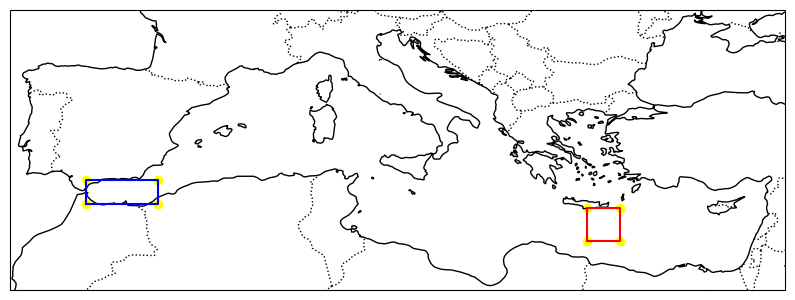

In [20]:
poly_coords = [(lonmin_alb, latmin_alb),(lonmin_alb, latmax_alb), (lonmax_alb, latmax_alb),(lonmax_alb, latmin_alb)]
poly_coords2 = [(lonmin_iera, latmin_iera),(lonmin_iera, latmax_iera), (lonmax_iera, latmax_iera),(lonmax_iera, latmin_iera)]

polygon = Polygon(poly_coords)
polygon2 = Polygon(poly_coords2)

def point_in_polygon(lon, lat):
    return polygon.contains(Point(lon, lat))

def point_in_polygon2(lon, lat):
    return polygon2.contains(Point(lon, lat))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(feature.BORDERS, linestyle=':')
ax.add_feature(feature.COASTLINE)
ax.set_extent([-10, 37, 30, 47], crs=ccrs.PlateCarree())
for lon, lat in poly_coords:
    plt.scatter(lon, lat, color='yellow', transform=ccrs.PlateCarree())
x, y = polygon.exterior.xy
plt.plot(x, y, transform=ccrs.PlateCarree(), color='blue')
for lon, lat in poly_coords2:
    plt.scatter(lon, lat, color='yellow', transform=ccrs.PlateCarree())
x, y = polygon2.exterior.xy
plt.plot(x, y, transform=ccrs.PlateCarree(), color='red')
plt.show()

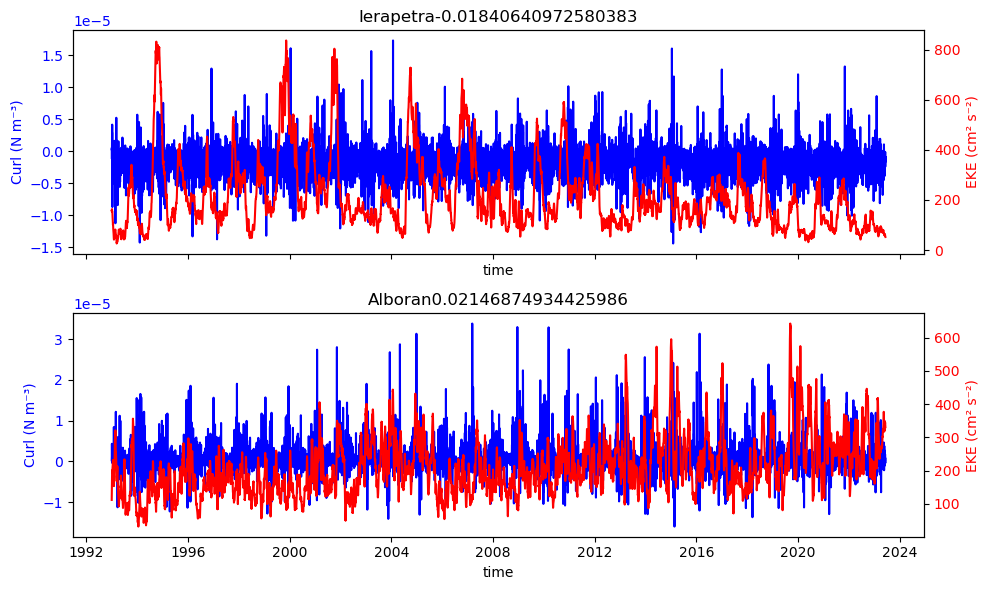

In [21]:
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 🔴 IERAPETRA
# axe 1 (curl)
wind_iera.curl.mean(("lat", "lon")).plot(ax=ax1, color="blue")
ax1.set_ylabel("Curl (N m⁻³)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
# axe 2 (EKE)
ax2 = ax1.twinx()
eke_iera.eke.mean(("lat", "lon")).plot(ax=ax2, color="red")
ax2.set_ylabel("EKE (cm² s⁻²)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

ax1.set_title("Ierapetra" + str(np.corrcoef(wind_iera.curl.mean(("lat", "lon")), eke_iera.eke.mean(("lat", "lon")))[0, 1]))

# 🔵 ALBORAN
# axe 1 (curl)
wind_alb.curl.mean(("lat", "lon")).plot(ax=ax3, color="blue")
ax3.set_ylabel("Curl (N m⁻³)", color="blue")
ax3.tick_params(axis="y", labelcolor="blue")
# axe 2 (EKE)
ax4 = ax3.twinx()
eke_alb.eke.mean(("lat", "lon")).plot(ax=ax4, color="red")
ax4.set_ylabel("EKE (cm² s⁻²)", color="red")
ax4.tick_params(axis="y", labelcolor="red")

ax3.set_title("Alboran" + str(np.corrcoef(wind_alb.curl.mean(("lat", "lon")), eke_alb.eke.mean(("lat", "lon")))[0, 1]))


plt.tight_layout()
plt.show()
